(10, 6)
Athlete     object
Country     object
Sport       object
Gold         int64
Silver       int64
Bronze     float64
dtype: object
          Athlete  Country       Sport  Gold  Silver  Bronze
0      Usain Bolt  Jamaica   Athletics     8       0     0.0
1  Michael Phelps      USA    Swimming    23       3     2.0
2    Simone Biles      USA  Gymnastics     7       2     2.0
Athlete    0
Country    0
Sport      0
Gold       0
Silver     0
Bronze     1
dtype: int64
Missing after cleaning: 0
            Gold     Silver     Bronze
count  10.000000  10.000000  10.000000
mean    7.000000   1.600000   0.500000
std     6.306963   1.577621   0.849837
min     1.000000   0.000000   0.000000
25%     3.250000   0.000000   0.000000
50%     7.000000   1.500000   0.000000
75%     7.750000   3.000000   0.750000
max    23.000000   4.000000   2.000000

Top Athlete:
 Athlete    Michael Phelps
Country               USA
Sport            Swimming
Gold                   23
Silver                  3
Bronze 

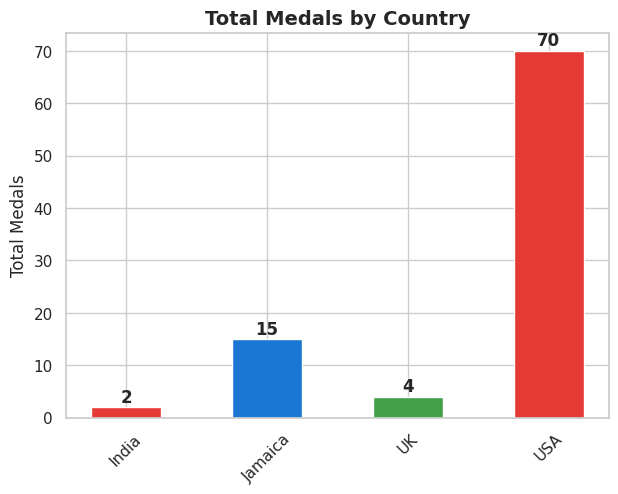

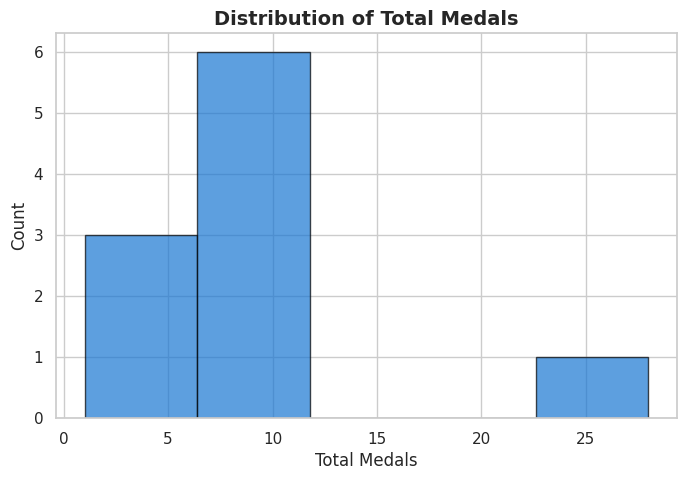

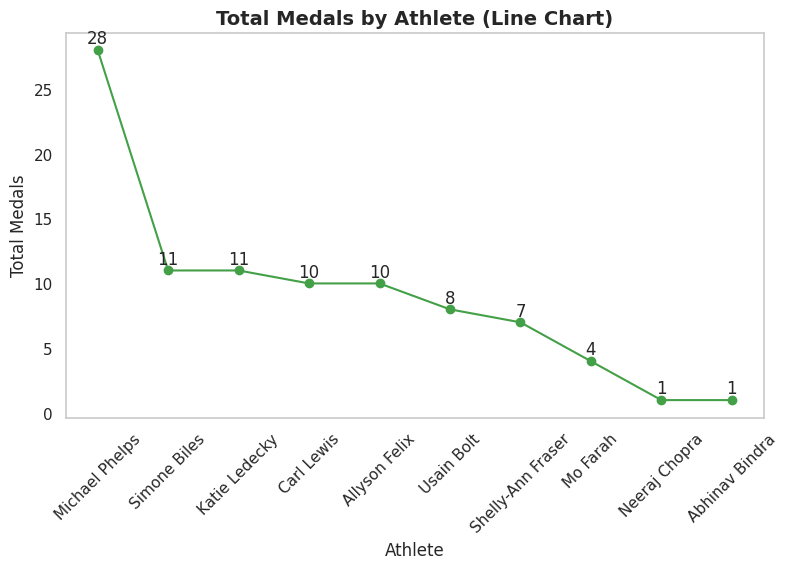

In [ ]:



# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# LOAD DATASET
data = {
    "Athlete": ["Usain Bolt", "Michael Phelps", "Simone Biles", "Neeraj Chopra", "Allyson Felix",
                "Carl Lewis", "Katie Ledecky", "Abhinav Bindra", "Mo Farah", "Shelly-Ann Fraser"],

    "Country": ["Jamaica", "USA", "USA", "India", "USA",
                "USA", "USA", "India", "UK", "Jamaica"],

    "Sport": ["Athletics", "Swimming", "Gymnastics", "Athletics", "Athletics",
              "Athletics", "Swimming", "Shooting", "Athletics", "Athletics"],

    "Gold": [8, 23, 7, 1, 7, 9, 7, 1, 4, 3],
    "Silver": [0, 3, 2, 0, 3, 1, 3, 0, 0, 4],
    "Bronze": [0, 2, 2, 0, None, 0, 1, 0, 0, 0]
}

df = pd.DataFrame(data)

print(df.shape)
print(df.dtypes)
print(df.head(3))






# STEP 1: IDENTIFY MISSING VALUES
print(df.isnull().sum())

# STEP 2: CLEAN DATA
df['Bronze'] = df['Bronze'].fillna(0)

# STEP 3: FIX DATA TYPES
df['Bronze'] = df['Bronze'].astype('int')

# STEP 4: VERIFY CLEANING
print('Missing after cleaning:', df.isnull().sum().sum())
print(df.describe())

# FEATURE ENGINEERING
df['Total'] = df[['Gold', 'Silver', 'Bronze']].sum(axis=1)


# Q1: Who is the top athlete?
top_athlete = df.sort_values(by='Total', ascending=False).iloc[0]
print("\nTop Athlete:\n", top_athlete)

# Q2: Total medals by country
country_total = df.groupby('Country', observed=False)['Total'].sum()
print("\nTotal Medals by Country:\n", country_total)

# Q3: Count of athletes by sport
sport_count = df.groupby('Sport', observed=False)['Sport'].count()
print("\nSport Counts:\n", sport_count)

# Q4: Average gold medals
avg_gold = df['Gold'].mean()
print(f"\nAverage Gold Medals: {avg_gold:.2f}")

# Q5: Total medals won by India
india_total = df[df['Country'] == 'India']['Total'].sum()
print("\nIndia Total Medals:", india_total)

# ─── CHART 1: TOTAL MEDALS BY COUNTRY (BAR CHART) ───────────────
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(country_total.index, country_total.values,
              color=['#E53935', '#1976D2', '#43A047'], width=0.5, edgecolor='white')
for bar, val in zip(bars, country_total.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+1,
            f'{val}', ha='center', fontweight='bold')
ax.set_title('Total Medals by Country', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Medals')
plt.xticks(rotation=45)
plt.show()

# CHART 2: DISTRIBUTION OF TOTAL MEDALS (HISTOGRAM)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['Total'], bins=5, alpha=0.7, color='#1976D2', edgecolor='black')
ax.set_title('Distribution of Total Medals', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Medals')
ax.set_ylabel('Count')
plt.show()
# CHART 3: TOTAL MEDALS BY ATHLETE (LINE CHART)
df_sorted = df.sort_values(by='Total', ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_sorted['Athlete'], df_sorted['Total'], marker='o', color='#43A047')
for x, y in zip(df_sorted['Athlete'], df_sorted['Total']):
    ax.text(x, y+0.5, str(y), ha='center')
ax.set_title('Total Medals by Athlete (Line Chart)', fontsize=14, fontweight='bold')
ax.set_xlabel('Athlete')
ax.set_ylabel('Total Medals')
plt.xticks(rotation=45)
plt.grid()
plt.show()

